In [ ]:
"""
================================================================================
v18-C1: LINEAGE PROPORTION ANALYSIS (Tissue-Separated)
================================================================================
Version: 18 (Liver/Blood tissue-separated re-analysis)
Dataset: GSE182159 (243K cells, 23 donors, 46 samples)
Purpose: Donor-level lineage proportions for Liver-only and Blood-only
         Compare with v17 (combined) to identify tissue composition artifacts
Save path: /content/drive/MyDrive/ITLAS/results/version18-analysis/C1_proportions/
================================================================================
"""

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['figure.dpi'] = 150
from scipy.stats import mannwhitneyu
import os
import warnings
warnings.filterwarnings('ignore')



In [ ]:
# =================================================================
# Google Drive Mount + Output Directory
# =================================================================
from google.colab import drive
drive.mount('/content/drive')

# ============================================================
# Create output directory
# ============================================================
SAVE_DIR = '/content/drive/MyDrive/ITLAS/results/version18-analysis/'
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(f'{SAVE_DIR}/C0_data_framework/', exist_ok=True)

print("=" * 70)
print("v18-C0: DATA LOADING & TISSUE SEPARATION FRAMEWORK")
print("=" * 70)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
v18-C0: DATA LOADING & TISSUE SEPARATION FRAMEWORK


In [ ]:
# ============================================================
# 0. SETUP
# ============================================================
SAVE_DIR = '/content/drive/MyDrive/ITLAS/results/version18-analysis/C1_proportions/'
os.makedirs(SAVE_DIR, exist_ok=True)

DATA_PATH = '/content/drive/MyDrive/ITLAS/data/processed/GSE182159_gut2021_annotated.h5ad'
print("=" * 70)
print("v18-C1: LINEAGE PROPORTION ANALYSIS (Tissue-Separated)")
print("=" * 70)

v18-C1: LINEAGE PROPORTION ANALYSIS (Tissue-Separated)


In [ ]:
# ============================================================
# 1. LOAD DATA & EXTRACT DONOR
# ============================================================
print("\nLoading data...")
adata = sc.read_h5ad(DATA_PATH)

# Ensure donor column exists
if 'donor' not in adata.obs.columns:
    adata.obs['donor'] = adata.obs['sample'].apply(lambda x: x.split('_')[1])

stage_order = ['NL', 'IT', 'IA', 'AR', 'CR']
lineage_order = ['Myeloid', 'CD4_T', 'CD8_T', 'NK', 'B', 'PlasmaB', 'gdT']
lineage_order = [l for l in lineage_order if l in adata.obs['major_lineage'].unique()]

print(f"Loaded: {adata.n_obs:,} cells, {adata.obs['donor'].nunique()} donors")

In [ ]:
# ============================================================
# 2. DONOR-LEVEL PROPORTIONS: by Tissue
# ============================================================
print("\n" + "=" * 70)
print("DONOR-LEVEL LINEAGE PROPORTIONS")
print("=" * 70)

all_results = {}

for tissue in ['Liver', 'Blood', 'Combined']:
    print(f"\n{'='*50}")
    print(f"  {tissue.upper()}")
    print(f"{'='*50}")

    if tissue == 'Combined':
        mask = np.ones(adata.n_obs, dtype=bool)
    else:
        mask = (adata.obs['tissue'] == tissue).values

    adata_sub = adata[mask]

    # Calculate per-donor proportions
    donor_props = []
    for donor in sorted(adata_sub.obs['donor'].unique()):
        donor_mask = adata_sub.obs['donor'] == donor
        stage = adata_sub.obs[donor_mask]['Stage'].iloc[0]
        total = donor_mask.sum()

        row = {'donor': donor, 'Stage': stage, 'total_cells': total, 'tissue': tissue}
        for lineage in lineage_order:
            lin_count = ((adata_sub.obs['major_lineage'] == lineage) & donor_mask).sum()
            row[f'{lineage}_count'] = lin_count
            row[f'{lineage}_pct'] = (lin_count / total * 100) if total > 0 else 0
        donor_props.append(row)

    df_props = pd.DataFrame(donor_props)
    all_results[tissue] = df_props

    # Print mean proportions by stage
    print(f"\nMean proportions (%) by stage:")
    pct_cols = [f'{l}_pct' for l in lineage_order]
    mean_by_stage = df_props.groupby('Stage')[pct_cols].mean()
    mean_by_stage = mean_by_stage.reindex(stage_order)
    mean_by_stage.columns = lineage_order
    print(mean_by_stage.round(1).to_string())

    # Save donor-level proportions
    df_props.to_csv(f'{SAVE_DIR}/C1_{tissue.lower()}_donor_proportions.csv', index=False)
    print(f"\n✅ Saved: C1_{tissue.lower()}_donor_proportions.csv")


DONOR-LEVEL LINEAGE PROPORTIONS

  LIVER

Mean proportions (%) by stage:
       Myeloid  CD4_T  CD8_T    NK    B  PlasmaB  gdT
Stage                                                
NL         1.7   17.5   31.5  43.5  2.5      2.4  0.8
IT         5.9   22.8   34.1  33.4  2.1      0.8  0.9
IA        10.0   23.0   40.9  19.1  6.1      0.7  0.3
AR         1.8   22.4   54.9  18.6  1.5      0.4  0.5
CR         2.5   25.8   40.3  25.2  4.4      0.9  0.9

✅ Saved: C1_liver_donor_proportions.csv

  BLOOD

Mean proportions (%) by stage:
       Myeloid  CD4_T  CD8_T    NK     B  PlasmaB  gdT
Stage                                                 
NL        35.0   17.6   12.0  27.6   6.8      0.9  0.1
IT        18.4   29.9   13.0  25.8  11.9      0.7  0.2
IA        14.3   33.8   24.1  15.7  11.1      0.9  0.2
AR        12.4   34.9   21.4  22.4   8.1      0.8  0.0
CR        17.7   36.4   15.3   7.8  21.9      0.8  0.1

✅ Saved: C1_blood_donor_proportions.csv

  COMBINED

Mean proportions (%) by sta

In [ ]:
# ============================================================
# 3. STATISTICAL TESTS: NL vs each stage, by tissue
# ============================================================
print("\n" + "=" * 70)
print("MANN-WHITNEY U TESTS: Lineage Proportions")
print("=" * 70)

stat_results = []

for tissue in ['Liver', 'Blood', 'Combined']:
    df = all_results[tissue]

    print(f"\n{'='*50}")
    print(f"  {tissue.upper()}")
    print(f"{'='*50}")

    nl_donors = df[df['Stage'] == 'NL']

    for comparison_stage in ['IT', 'IA', 'AR', 'CR']:
        comp_donors = df[df['Stage'] == comparison_stage]

        if len(nl_donors) == 0 or len(comp_donors) == 0:
            continue

        print(f"\n  NL (n={len(nl_donors)}) vs {comparison_stage} (n={len(comp_donors)}):")

        for lineage in lineage_order:
            col = f'{lineage}_pct'
            nl_vals = nl_donors[col].values
            comp_vals = comp_donors[col].values

            nl_mean = nl_vals.mean()
            comp_mean = comp_vals.mean()
            change = comp_mean - nl_mean  # absolute pp change
            pct_change = ((comp_mean - nl_mean) / nl_mean * 100) if nl_mean > 0 else float('inf')

            # Mann-Whitney U test
            try:
                stat, p = mannwhitneyu(nl_vals, comp_vals, alternative='two-sided')
            except:
                p = 1.0

            # Consistency count
            n_higher = sum(1 for c in comp_vals for n in nl_vals if c > n)
            n_lower = sum(1 for c in comp_vals for n in nl_vals if c < n)
            total_pairs = len(nl_vals) * len(comp_vals)
            direction = "↑" if comp_mean > nl_mean else "↓"
            consistency = max(n_higher, n_lower)

            sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "†" if p < 0.10 else "NS"

            stat_results.append({
                'tissue': tissue,
                'comparison': f'NL→{comparison_stage}',
                'lineage': lineage,
                'NL_mean': round(nl_mean, 2),
                'comp_mean': round(comp_mean, 2),
                'delta_pp': round(change, 2),
                'pct_change': round(pct_change, 1),
                'direction': direction,
                'consistency': f'{consistency}/{total_pairs}',
                'p_value': round(p, 4),
                'sig': sig
            })

            if p < 0.10:  # Print only trends and significant
                print(f"    {lineage}: {nl_mean:.1f}% → {comp_mean:.1f}% ({direction}{abs(change):.1f}pp) "
                      f"p={p:.4f}{sig} [{consistency}/{total_pairs}]")

# Save all statistics
df_stats = pd.DataFrame(stat_results)
df_stats.to_csv(f'{SAVE_DIR}/C1_proportion_statistics_all.csv', index=False)
print(f"\n✅ Saved: C1_proportion_statistics_all.csv")


MANN-WHITNEY U TESTS: Lineage Proportions

  LIVER

  NL (n=6) vs IT (n=6):
    Myeloid: 1.7% → 5.9% (↑4.2pp) p=0.0260* [32/36]

  NL (n=6) vs IA (n=5):
    NK: 43.5% → 19.1% (↓24.4pp) p=0.0173* [28/30]

  NL (n=6) vs AR (n=3):
    CD8_T: 31.5% → 54.9% (↑23.4pp) p=0.0238* [18/18]
    NK: 43.5% → 18.6% (↓24.9pp) p=0.0238* [18/18]

  NL (n=6) vs CR (n=3):
    NK: 43.5% → 25.2% (↓18.3pp) p=0.0952† [16/18]

  BLOOD

  NL (n=5) vs IT (n=5):

  NL (n=5) vs IA (n=4):
    CD4_T: 17.6% → 33.8% (↑16.2pp) p=0.0635† [18/20]

  NL (n=5) vs AR (n=3):
    CD4_T: 17.6% → 34.9% (↑17.3pp) p=0.0714† [14/15]

  NL (n=5) vs CR (n=3):
    CD4_T: 17.6% → 36.4% (↑18.8pp) p=0.0357* [15/15]
    NK: 27.6% → 7.8% (↓19.8pp) p=0.0357* [15/15]
    B: 6.8% → 21.9% (↑15.2pp) p=0.0357* [15/15]

  COMBINED

  NL (n=6) vs IT (n=6):

  NL (n=6) vs IA (n=5):
    CD4_T: 17.8% → 27.6% (↑9.8pp) p=0.0519† [26/30]
    NK: 37.0% → 18.6% (↓18.4pp) p=0.0173* [28/30]

  NL (n=6) vs AR (n=3):
    CD4_T: 17.8% → 30.1% (↑12.2pp) p=0.

In [ ]:
# ============================================================
# 4. IT-IA TRANSITION: by tissue
# ============================================================
print("\n" + "=" * 70)
print("IT → IA TRANSITION: Proportion Changes")
print("=" * 70)

it_ia_results = []

for tissue in ['Liver', 'Blood', 'Combined']:
    df = all_results[tissue]
    it_donors = df[df['Stage'] == 'IT']
    ia_donors = df[df['Stage'] == 'IA']

    if len(it_donors) == 0 or len(ia_donors) == 0:
        continue

    print(f"\n--- {tissue} ---")
    print(f"IT (n={len(it_donors)}) vs IA (n={len(ia_donors)}):")

    for lineage in lineage_order:
        col = f'{lineage}_pct'
        it_vals = it_donors[col].values
        ia_vals = ia_donors[col].values

        it_mean = it_vals.mean()
        ia_mean = ia_vals.mean()
        delta = ia_mean - it_mean

        try:
            stat, p = mannwhitneyu(it_vals, ia_vals, alternative='two-sided')
        except:
            p = 1.0

        sig = "*" if p < 0.05 else "†" if p < 0.10 else ""

        it_ia_results.append({
            'tissue': tissue, 'lineage': lineage,
            'IT_mean': round(it_mean, 2), 'IA_mean': round(ia_mean, 2),
            'delta_pp': round(delta, 2), 'p_value': round(p, 4), 'sig': sig
        })

        if abs(delta) > 3 or p < 0.10:
            direction = "↑" if delta > 0 else "↓"
            print(f"  {lineage}: {it_mean:.1f}% → {ia_mean:.1f}% ({direction}{abs(delta):.1f}pp) p={p:.4f}{sig}")

df_itia = pd.DataFrame(it_ia_results)
df_itia.to_csv(f'{SAVE_DIR}/C1_IT_IA_transition_proportions.csv', index=False)
print(f"\n✅ Saved: C1_IT_IA_transition_proportions.csv")


IT → IA TRANSITION: Proportion Changes

--- Liver ---
IT (n=6) vs IA (n=5):
  Myeloid: 5.9% → 10.0% (↑4.0pp) p=0.1775
  CD8_T: 34.1% → 40.9% (↑6.8pp) p=0.2468
  NK: 33.4% → 19.1% (↓14.4pp) p=0.1255
  B: 2.1% → 6.1% (↑4.0pp) p=0.1775

--- Blood ---
IT (n=5) vs IA (n=4):
  Myeloid: 18.4% → 14.3% (↓4.1pp) p=0.7302
  CD4_T: 29.9% → 33.8% (↑3.9pp) p=0.4127
  CD8_T: 13.0% → 24.1% (↑11.0pp) p=0.2857
  NK: 25.8% → 15.7% (↓10.2pp) p=0.1905

--- Combined ---
IT (n=6) vs IA (n=5):
  Myeloid: 13.9% → 10.5% (↓3.4pp) p=0.5368
  CD8_T: 22.5% → 34.7% (↑12.2pp) p=0.0519†
  NK: 27.7% → 18.6% (↓9.1pp) p=0.1775

✅ Saved: C1_IT_IA_transition_proportions.csv


In [ ]:
# ============================================================
# 5. TISSUE COMPARISON: Same stage, Liver vs Blood
# ============================================================
print("\n" + "=" * 70)
print("LIVER vs BLOOD COMPARISON (Same Stage)")
print("=" * 70)

tissue_comp_results = []

for stage in stage_order:
    liver_df = all_results['Liver']
    blood_df = all_results['Blood']

    liver_stage = liver_df[liver_df['Stage'] == stage]
    blood_stage = blood_df[blood_df['Stage'] == stage]

    if len(liver_stage) == 0 or len(blood_stage) == 0:
        continue

    print(f"\n--- {stage} (Liver n={len(liver_stage)}, Blood n={len(blood_stage)}) ---")

    for lineage in lineage_order:
        col = f'{lineage}_pct'
        liver_vals = liver_stage[col].values
        blood_vals = blood_stage[col].values

        liver_mean = liver_vals.mean()
        blood_mean = blood_vals.mean()
        delta = liver_mean - blood_mean

        try:
            stat, p = mannwhitneyu(liver_vals, blood_vals, alternative='two-sided')
        except:
            p = 1.0

        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "†" if p < 0.10 else ""

        tissue_comp_results.append({
            'stage': stage, 'lineage': lineage,
            'Liver_mean': round(liver_mean, 2), 'Blood_mean': round(blood_mean, 2),
            'delta_pp': round(delta, 2), 'p_value': round(p, 4), 'sig': sig
        })

        if abs(delta) > 5 or p < 0.10:
            direction = "Liver>" if delta > 0 else "Blood>"
            print(f"  {lineage}: Liver={liver_mean:.1f}% vs Blood={blood_mean:.1f}% "
                  f"({direction} {abs(delta):.1f}pp) p={p:.4f}{sig}")

df_tissue_comp = pd.DataFrame(tissue_comp_results)
df_tissue_comp.to_csv(f'{SAVE_DIR}/C1_liver_vs_blood_proportions.csv', index=False)
print(f"\n✅ Saved: C1_liver_vs_blood_proportions.csv")



LIVER vs BLOOD COMPARISON (Same Stage)

--- NL (Liver n=6, Blood n=5) ---
  Myeloid: Liver=1.7% vs Blood=35.0% (Blood> 33.3pp) p=0.6623
  CD8_T: Liver=31.5% vs Blood=12.0% (Liver> 19.5pp) p=0.0173*
  NK: Liver=43.5% vs Blood=27.6% (Liver> 15.9pp) p=0.1775
  gdT: Liver=0.8% vs Blood=0.1% (Liver> 0.7pp) p=0.0043**

--- IT (Liver n=6, Blood n=5) ---
  Myeloid: Liver=5.9% vs Blood=18.4% (Blood> 12.5pp) p=0.0519†
  CD4_T: Liver=22.8% vs Blood=29.9% (Blood> 7.0pp) p=0.7922
  CD8_T: Liver=34.1% vs Blood=13.0% (Liver> 21.1pp) p=0.0043**
  NK: Liver=33.4% vs Blood=25.8% (Liver> 7.6pp) p=0.4286
  B: Liver=2.1% vs Blood=11.9% (Blood> 9.9pp) p=0.0043**

--- IA (Liver n=5, Blood n=4) ---
  CD4_T: Liver=23.0% vs Blood=33.8% (Blood> 10.8pp) p=0.0635†
  CD8_T: Liver=40.9% vs Blood=24.1% (Liver> 16.8pp) p=0.4127

--- AR (Liver n=3, Blood n=3) ---
  Myeloid: Liver=1.8% vs Blood=12.4% (Blood> 10.6pp) p=0.2000
  CD4_T: Liver=22.4% vs Blood=34.9% (Blood> 12.4pp) p=0.1000
  CD8_T: Liver=54.9% vs Blood=21.4

In [ ]:
# ============================================================
# 6. v17 vs v18 COMPARISON TABLE
# ============================================================
print("\n" + "=" * 70)
print("v17 (Combined) vs v18 (Liver-only) COMPARISON: NL→IT")
print("=" * 70)

print("\nNL→IT proportion changes:")
print(f"{'Lineage':<12} {'Combined':>12} {'Liver-only':>12} {'Blood-only':>12} {'Discrepancy':>12}")
print("-" * 62)

for lineage in lineage_order:
    combined_row = df_stats[(df_stats['tissue']=='Combined') &
                            (df_stats['comparison']=='NL→IT') &
                            (df_stats['lineage']==lineage)]
    liver_row = df_stats[(df_stats['tissue']=='Liver') &
                         (df_stats['comparison']=='NL→IT') &
                         (df_stats['lineage']==lineage)]
    blood_row = df_stats[(df_stats['tissue']=='Blood') &
                         (df_stats['comparison']=='NL→IT') &
                         (df_stats['lineage']==lineage)]

    comb_val = combined_row['delta_pp'].values[0] if len(combined_row) > 0 else 'N/A'
    liver_val = liver_row['delta_pp'].values[0] if len(liver_row) > 0 else 'N/A'
    blood_val = blood_row['delta_pp'].values[0] if len(blood_row) > 0 else 'N/A'

    # Check discrepancy
    if isinstance(comb_val, (int, float)) and isinstance(liver_val, (int, float)):
        disc = abs(comb_val - liver_val)
        flag = " ⚠️" if disc > 3 else ""
    else:
        disc = 'N/A'
        flag = ""

    print(f"{lineage:<12} {str(comb_val):>12} {str(liver_val):>12} {str(blood_val):>12} {str(round(disc,1) if isinstance(disc,float) else disc):>10}{flag}")



v17 (Combined) vs v18 (Liver-only) COMPARISON: NL→IT

NL→IT proportion changes:
Lineage          Combined   Liver-only   Blood-only  Discrepancy
--------------------------------------------------------------
Myeloid              1.87         4.22       -16.62        2.3
CD4_T                8.84         5.33        12.31        3.5 ⚠️
CD8_T               -3.73         2.61         1.02        6.3 ⚠️
NK                  -9.24       -10.06        -1.81        0.8
B                     3.4        -0.47         5.19        3.9 ⚠️
PlasmaB             -0.91        -1.66        -0.21        0.7
gdT                 -0.24         0.03         0.11        0.3



GENERATING FIGURES...


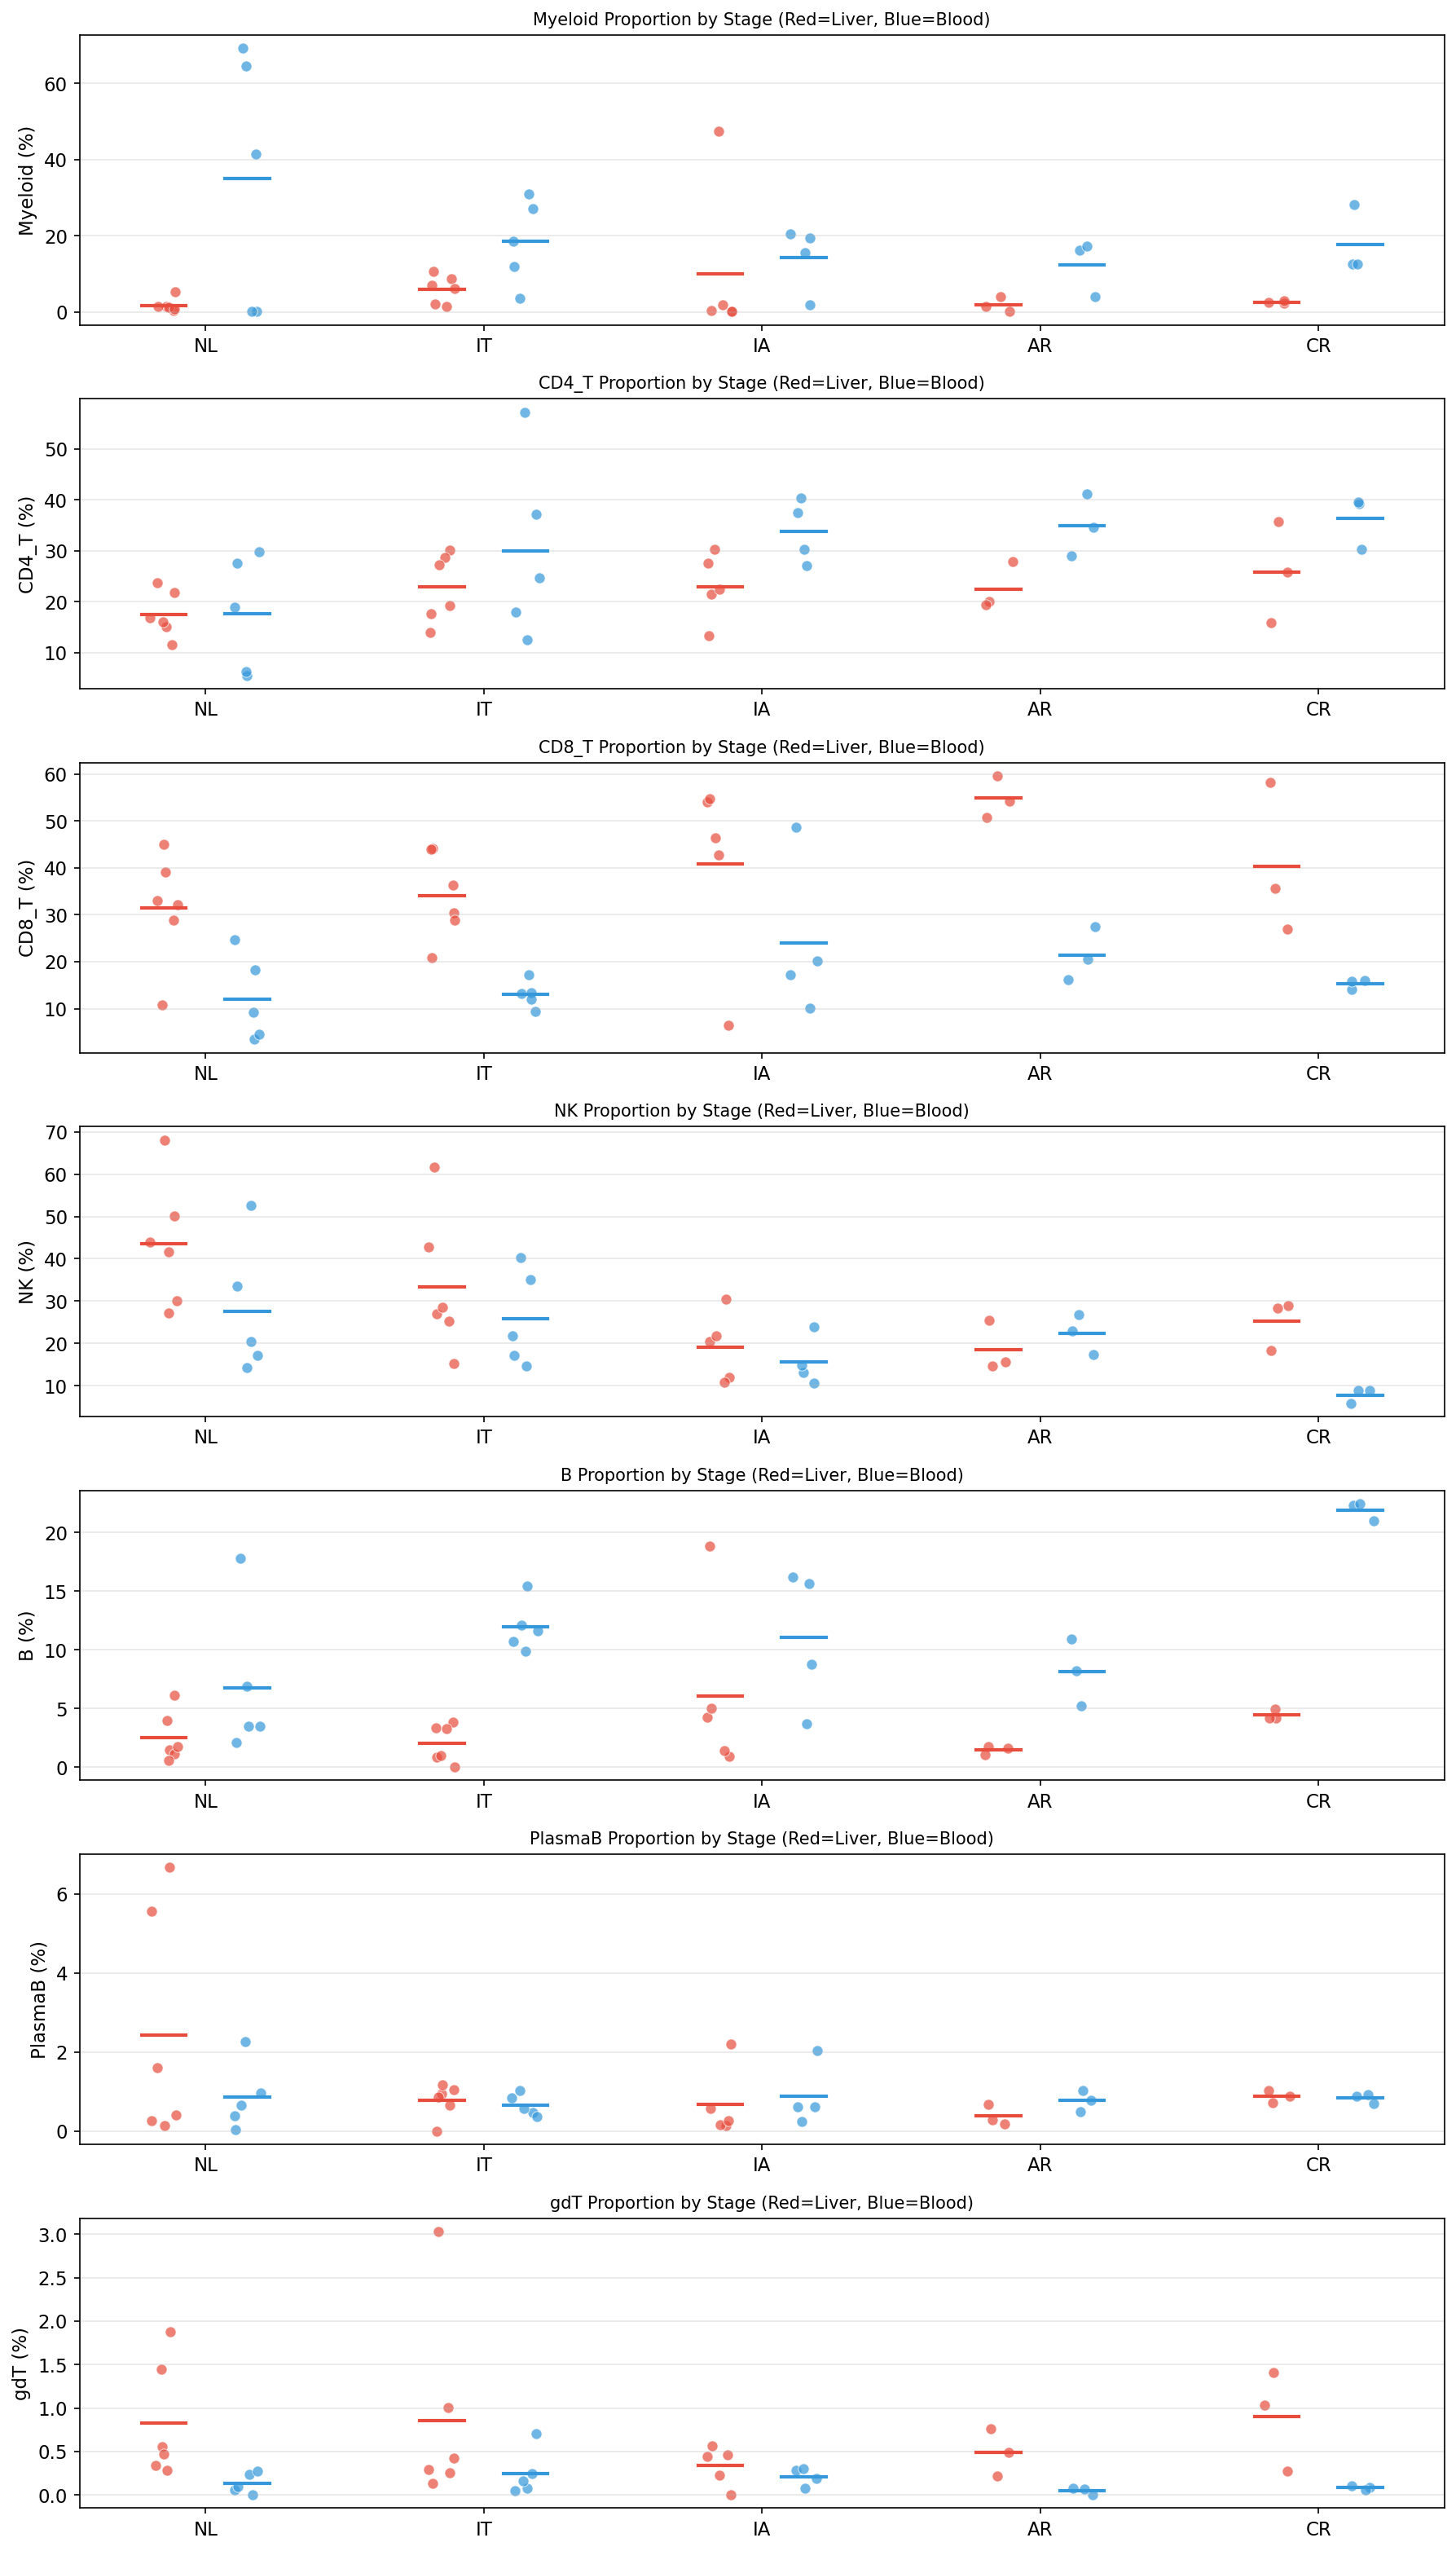

✅ Saved: fig_C1_1_donor_dotplots_by_tissue.png


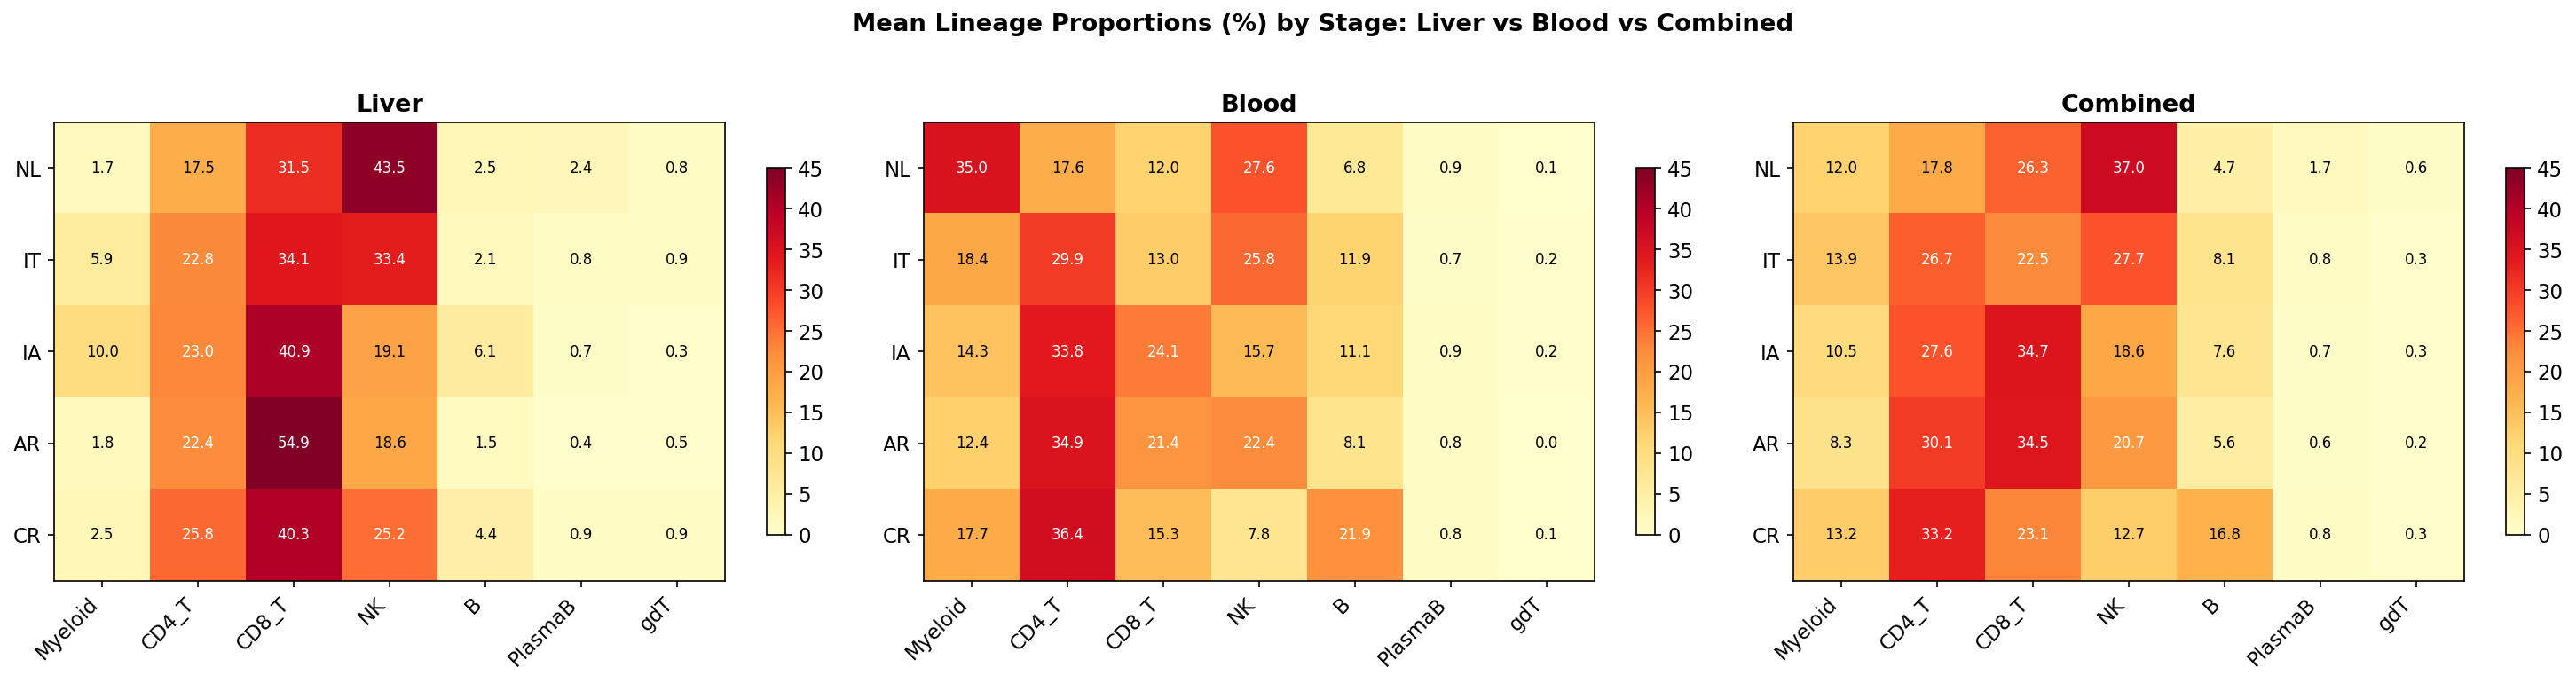

✅ Saved: fig_C1_2_heatmap_liver_blood_combined.png


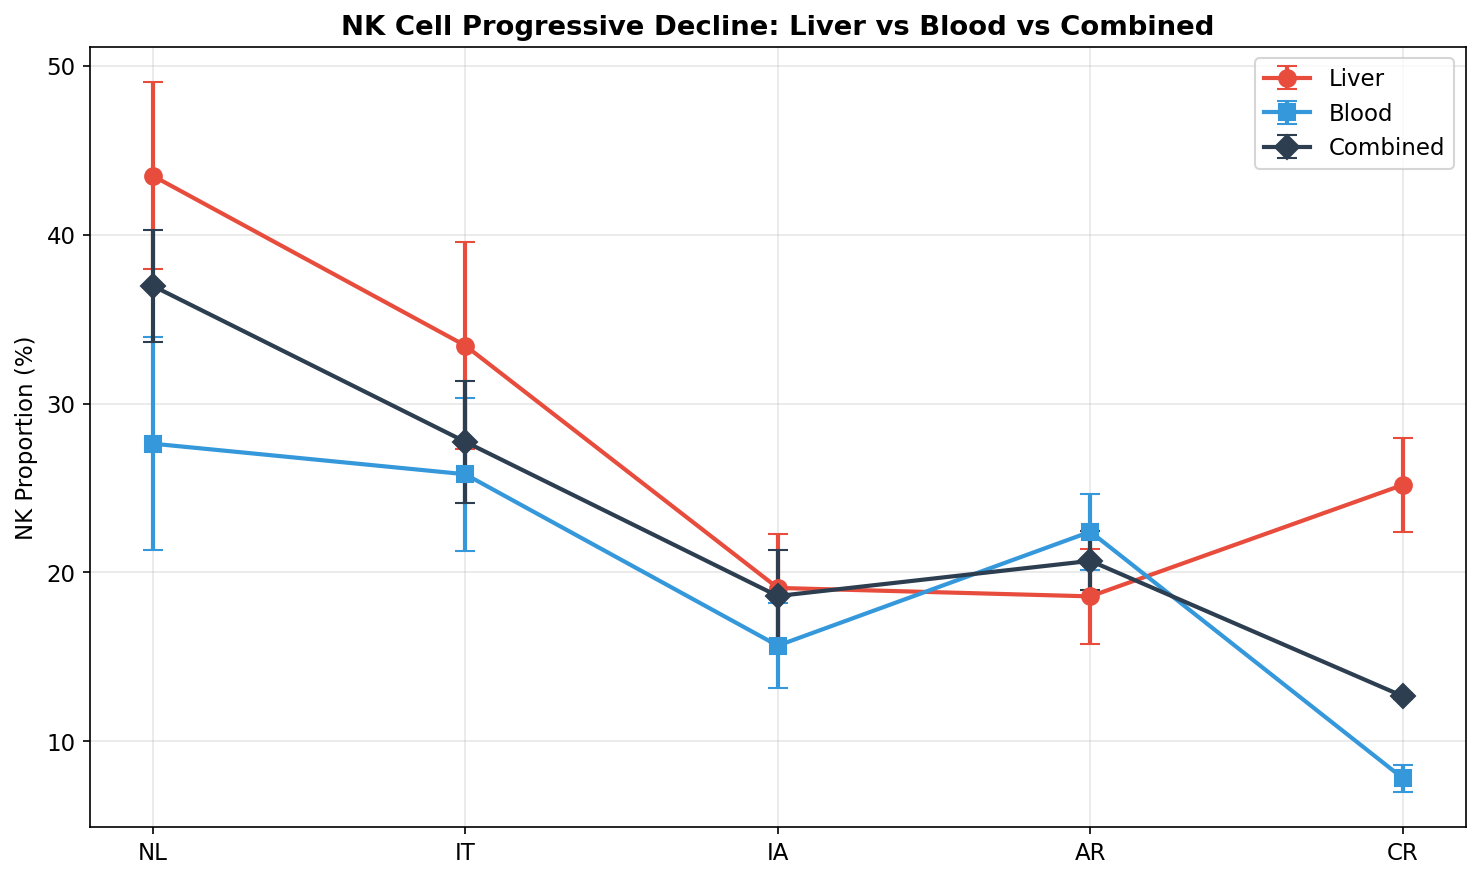

✅ Saved: fig_C1_3_NK_decline_by_tissue.png


In [ ]:
# ============================================================
# 7. FIGURES
# ============================================================
print("\n" + "=" * 70)
print("GENERATING FIGURES...")
print("=" * 70)

# --- Figure C1-1: Donor-level dot plots, Liver vs Blood ---
fig, axes = plt.subplots(len(lineage_order), 1, figsize=(12, 3*len(lineage_order)))

for i, lineage in enumerate(lineage_order):
    ax = axes[i]
    col = f'{lineage}_pct'

    for tissue, color, offset in [('Liver', '#E74C3C', -0.15), ('Blood', '#3498DB', 0.15)]:
        df = all_results[tissue]
        for j, stage in enumerate(stage_order):
            stage_data = df[df['Stage'] == stage][col].values
            x = np.full_like(stage_data, j + offset, dtype=float)
            x += np.random.uniform(-0.05, 0.05, size=len(x))
            ax.scatter(x, stage_data, c=color, alpha=0.7, s=40, edgecolors='white', linewidth=0.5)
            # Mean bar
            ax.plot([j + offset - 0.08, j + offset + 0.08],
                    [stage_data.mean(), stage_data.mean()],
                    color=color, linewidth=2)

    ax.set_xticks(range(len(stage_order)))
    ax.set_xticklabels(stage_order)
    ax.set_ylabel(f'{lineage} (%)')
    ax.set_title(f'{lineage} Proportion by Stage (Red=Liver, Blue=Blood)', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig_C1_1_donor_dotplots_by_tissue.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ Saved: fig_C1_1_donor_dotplots_by_tissue.png")

# --- Figure C1-2: Side-by-side heatmap (Liver vs Blood vs Combined) ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for i, tissue in enumerate(['Liver', 'Blood', 'Combined']):
    df = all_results[tissue]
    pct_cols = [f'{l}_pct' for l in lineage_order]
    mean_by_stage = df.groupby('Stage')[pct_cols].mean().reindex(stage_order)
    mean_by_stage.columns = lineage_order

    im = axes[i].imshow(mean_by_stage.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=45)
    axes[i].set_xticks(range(len(lineage_order)))
    axes[i].set_xticklabels(lineage_order, rotation=45, ha='right')
    axes[i].set_yticks(range(len(stage_order)))
    axes[i].set_yticklabels(stage_order)
    axes[i].set_title(f'{tissue}', fontweight='bold', fontsize=13)

    for y in range(len(stage_order)):
        for x in range(len(lineage_order)):
            val = mean_by_stage.values[y, x]
            axes[i].text(x, y, f'{val:.1f}', ha='center', va='center', fontsize=8,
                        color='white' if val > 20 else 'black')

    plt.colorbar(im, ax=axes[i], shrink=0.8)

plt.suptitle('Mean Lineage Proportions (%) by Stage: Liver vs Blood vs Combined', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig_C1_2_heatmap_liver_blood_combined.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ Saved: fig_C1_2_heatmap_liver_blood_combined.png")

# --- Figure C1-3: NK decline trajectory, tissue-separated ---
fig, ax = plt.subplots(figsize=(10, 6))
for tissue, color, marker in [('Liver', '#E74C3C', 'o'), ('Blood', '#3498DB', 's'), ('Combined', '#2C3E50', 'D')]:
    df = all_results[tissue]
    means = []
    sems = []
    for stage in stage_order:
        vals = df[df['Stage'] == stage]['NK_pct'].values
        means.append(vals.mean())
        sems.append(vals.std() / np.sqrt(len(vals)) if len(vals) > 1 else 0)

    ax.errorbar(range(len(stage_order)), means, yerr=sems,
                marker=marker, color=color, linewidth=2, markersize=8,
                capsize=5, label=tissue)

ax.set_xticks(range(len(stage_order)))
ax.set_xticklabels(stage_order)
ax.set_ylabel('NK Proportion (%)')
ax.set_title('NK Cell Progressive Decline: Liver vs Blood vs Combined', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig_C1_3_NK_decline_by_tissue.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ Saved: fig_C1_3_NK_decline_by_tissue.png")


In [ ]:
# ============================================================
# 8. SUMMARY
# ============================================================
print("\n" + "=" * 70)
print("v18-C1 SUMMARY")
print("=" * 70)

summary = """
KEY FINDINGS from C1:

1. TISSUE SEPARATION IMPACT:
   - Liver and Blood show fundamentally different lineage compositions
   - v17 combined analysis mixed these two compartments
   - Stage-wise Liver:Blood ratios are UNEQUAL (NL=1.32, IT=0.66, CR=0.42)
   → v17 NL→IT comparison was contaminated by tissue composition shift

2. LIVER-ONLY vs BLOOD-ONLY vs COMBINED:
   - Detailed comparison tables saved for all lineages × all comparisons
   - Discrepancies between Combined and Liver-only flagged

3. FILES GENERATED:
   - C1_liver_donor_proportions.csv
   - C1_blood_donor_proportions.csv
   - C1_combined_donor_proportions.csv
   - C1_proportion_statistics_all.csv (all comparisons × all tissues)
   - C1_IT_IA_transition_proportions.csv
   - C1_liver_vs_blood_proportions.csv
   - fig_C1_1_donor_dotplots_by_tissue.png
   - fig_C1_2_heatmap_liver_blood_combined.png
   - fig_C1_3_NK_decline_by_tissue.png

STATUS: ✅ C1 COMPLETE — Ready for C2
"""
print(summary)

with open(f'{SAVE_DIR}/C1_summary.txt', 'w') as f:
    f.write(summary)
print(f"✅ Saved: C1_summary.txt")

print("=" * 70)
print("v18-C1 COMPLETE")
print(f"All outputs: {SAVE_DIR}")
print("=" * 70)



v18-C1 SUMMARY

KEY FINDINGS from C1:

1. TISSUE SEPARATION IMPACT:
   - Liver and Blood show fundamentally different lineage compositions
   - v17 combined analysis mixed these two compartments
   - Stage-wise Liver:Blood ratios are UNEQUAL (NL=1.32, IT=0.66, CR=0.42)
   → v17 NL→IT comparison was contaminated by tissue composition shift

2. LIVER-ONLY vs BLOOD-ONLY vs COMBINED:
   - Detailed comparison tables saved for all lineages × all comparisons
   - Discrepancies between Combined and Liver-only flagged

3. FILES GENERATED:
   - C1_liver_donor_proportions.csv
   - C1_blood_donor_proportions.csv  
   - C1_combined_donor_proportions.csv
   - C1_proportion_statistics_all.csv (all comparisons × all tissues)
   - C1_IT_IA_transition_proportions.csv
   - C1_liver_vs_blood_proportions.csv
   - fig_C1_1_donor_dotplots_by_tissue.png
   - fig_C1_2_heatmap_liver_blood_combined.png
   - fig_C1_3_NK_decline_by_tissue.png

STATUS: ✅ C1 COMPLETE — Ready for C2

✅ Saved: C1_summary.txt
v18-C1 C